# Yangtze River power outage attribution analysis

## Energy Demend (CDD)

### Step 1 Dataset preparation
Historical long term 15 ensembles
Observational dataset (CN05)
HadGEM factual 525 ensembles
HadEGM counterfactual 525 ensembles

In [1]:
pwd

'/home/users/weijia_6/Yangtze_code'

In [2]:
# New path for the long term historical 15 ensembles - daily temperature
path = "/gws/ssde/j25a/cssp_china/wp1/HadGEM3-A-N216-CHINAcut/historical/tas/day"

In [1]:
# Import packages
import xarray as xr
import numpy as np
import pandas as pd

In [6]:
# Have a look of one of the historical data (1 decade, 1 emsemble)
x = xr.open_dataset(path+"/tas_day_HadGEM3-A-N216_historical_r1i1p10_19600101-19691230-CHINA.nc")

In [7]:
x.time

<xarray.DataArray 'time' (time: 3600)> Size: 29kB
array([cftime.Datetime360Day(1960, 1, 1, 12, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(1960, 1, 2, 12, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(1960, 1, 3, 12, 0, 0, 0, has_year_zero=True), ...,
       cftime.Datetime360Day(1969, 12, 28, 12, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(1969, 12, 29, 12, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(1969, 12, 30, 12, 0, 0, 0, has_year_zero=True)],
      shape=(3600,), dtype=object)
Coordinates:
    height   float64 8B ...
  * time     (time) object 29kB 1960-01-01 12:00:00 ... 1969-12-30 12:00:00
Attributes:
    bounds:         time_bnds
    axis:           T
    long_name:      time
    standard_name:  time

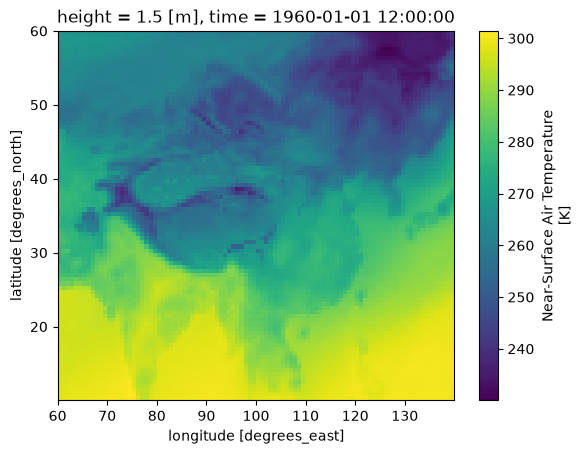

In [8]:
# plot a snapshot

x.tas[0].plot()

In [9]:
# To get the long-term HadGEM dataset (1961-2013 15 ensembles)

path = "/gws/ssde/j25a/cssp_china/wp1/HadGEM3-A-N216-CHINAcut/historical/tas/day"

names = [
    "19600101-19691230",
    "19700101-19791230",
    "19800101-19891230",
    "19900101-19991230",
    "20000101-20091230",
    "20100101-20131230"
]

def clean(ds):
    """Drop problematic variables and keep only tas."""
    drop_vars = [v for v in ["height", "lon_bnds", "lat_bnds", "time_bnds"] if v in ds]
    if drop_vars:
        ds = ds.drop_vars(drop_vars)
    return ds[["tas"]]   # keep only tas

# Loop over ensembles p1–p15
for p in np.arange(1, 16):

    print(f"Loading ensemble p{p}")

    first = True

    for n in names:

        fname = f"{path}/tas_day_HadGEM3-A-N216_historical_r1i1p{p}_{n}-CHINA.nc"
        ds = xr.open_dataset(fname)

        # Clean dataset
        ds = clean(ds)

        # Slice to valid 360-day calendar range
        ds = ds.sel(time=slice("1961-01-01", "2013-12-30"))

        if first:
            total = ds
            first = False
        else:
            total = xr.concat([total, ds], dim="time", coords="minimal", compat="override")

    # Add ensemble dimension
    total = total.expand_dims({"number": [p]})

    # Build final dataset
    if p == 1:
        total_temp = total
    else:
        total_temp = xr.concat([total_temp, total], dim="number", coords="minimal", compat="override")

# Save final dataset
total_temp.to_netcdf("/home/users/weijia_6/Yangtze_code/HADGEM_1961_2013_his.nc")
print("Saved final dataset.")

Loading ensemble p1
Loading ensemble p2
Loading ensemble p3
Loading ensemble p4
Loading ensemble p5
Loading ensemble p6
Loading ensemble p7
Loading ensemble p8
Loading ensemble p9
Loading ensemble p10
Loading ensemble p11
Loading ensemble p12
Loading ensemble p13
Loading ensemble p14
Loading ensemble p15
Saved final dataset.


<xarray.Dataset> Size: 10GB
Dimensions:  (number: 15, time: 19080, lat: 90, lon: 96)
Coordinates:
  * number   (number) int64 120B 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
  * lat      (lat) float64 720B 10.28 10.83 11.39 11.94 ... 58.61 59.17 59.72
  * lon      (lon) float64 768B 60.42 61.25 62.08 62.92 ... 137.9 138.7 139.6
  * time     (time) object 153kB 1961-01-01 12:00:00 ... 2013-12-30 12:00:00
Data variables:
    tas      (number, time, lat, lon) float32 10GB ...
Attributes: (12/28)
    institution:            Met Office Hadley Centre, Fitzroy Road, Exeter, D...
    institute_id:           MOHC
    experiment_id:          historical
    source:                 MOHC Unified Model [N216L85]
    model_id:               HadGEM3-A-N216
    forcing:                GHG, Oz, LU, Sl, Vl, AA, (GHG = CO2, N2O, CH4, CF...
    ...                     ...
    title:                  HadGEM3-A-N216 model output prepared for EUCLEIA ...
    parent_experiment:      N/A
    modeling_realm:         at

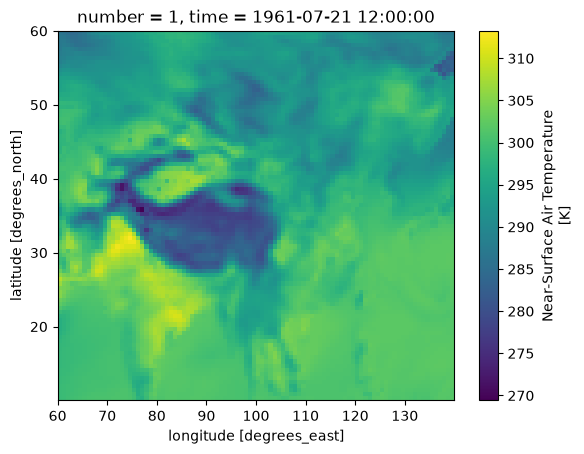

In [14]:
# Check data
import xarray as xr
ds = xr.open_dataset("/home/users/weijia_6/Yangtze_code/HADGEM_1961_2013_his.nc")
print(ds)
ds.tas.isel(number=0, time=200).values.min(), ds.tas.isel(number=0, time=200).values.max()
ds['tas'].isel(number=0, time=200).plot()

In [12]:
# Get the long-term historical Model & long-term CN05 (obs) consistently

# Get 1961-2013 daily Tm data for both CN05 and HadGEM data (keep them to same resolution as well)
# HadGEM: ~60 km
# CN05: 0.25˚

In [15]:
tm_path = xr.open_dataset("/home/users/weijia_6/Yangtze_code/HADGEM_1961_2013_his.nc")

# tm_path['tas'].isel(number=0, time=0).plot()
# tm_path['tas'].isel(number=0, time=-1).plot()

In [16]:
# Check the time arrangment in HadGEM data (12 month x 30 days for all years)
ds.time

<xarray.DataArray 'time' (time: 19080)> Size: 153kB
array([cftime.Datetime360Day(1961, 1, 1, 12, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(1961, 1, 2, 12, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(1961, 1, 3, 12, 0, 0, 0, has_year_zero=True), ...,
       cftime.Datetime360Day(2013, 12, 28, 12, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(2013, 12, 29, 12, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(2013, 12, 30, 12, 0, 0, 0, has_year_zero=True)],
      shape=(19080,), dtype=object)
Coordinates:
  * time     (time) object 153kB 1961-01-01 12:00:00 ... 2013-12-30 12:00:00
Attributes:
    bounds:         time_bnds
    axis:           T
    long_name:      time
    standard_name:  time

In [17]:
# Get the 1961-2013 long term HadGEM data
tm_HadGEM_LT = tm_path.sel(time = slice("1961-01-01", "2013-12-30"))

In [3]:
# Hadgem data is 30 days per month, so 360 days for a year, so we need to trim it a bit for later bias correction
# Drop all 29th and 30th Feb in HadGEM data

import xarray as xr
import numpy as np

# Open lazily (no data loaded into memory)
ds = xr.open_dataset("/home/users/weijia_6/Yangtze_code/HADGEM_1961_2013_his.nc")

# Read time coordinate only (small)
times = ds['time'].values   # cftime.Datetime360Day objects

# Extract month and day (cheap operation)
months = np.array([t.month for t in times], dtype=np.int16)
days   = np.array([t.day   for t in times], dtype=np.int16)

# Build keep mask: drop BOTH 29 and 30 Feb
keep_mask = ~((months == 2) & (days >= 29))
keep_idx = np.nonzero(keep_mask)[0]

# Select using integer indexing (memory efficient)
ds_noleap = ds.isel(time=keep_idx)

tm_HadGEM_LT_1 = ds_noleap

# # Write out (streamed)
# ds_noleap.to_netcdf("out_daily_360day_no_feb29_30.nc", format="NETCDF4")

In [4]:
# Now there should be 53 years * (360 days - 2 days) = 18974 time points in total
tm_HadGEM_LT_1.time

<xarray.DataArray 'time' (time: 18974)> Size: 152kB
array([cftime.Datetime360Day(1961, 1, 1, 12, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(1961, 1, 2, 12, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(1961, 1, 3, 12, 0, 0, 0, has_year_zero=True), ...,
       cftime.Datetime360Day(2013, 12, 28, 12, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(2013, 12, 29, 12, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(2013, 12, 30, 12, 0, 0, 0, has_year_zero=True)],
      shape=(18974,), dtype=object)
Coordinates:
  * time     (time) object 152kB 1961-01-01 12:00:00 ... 2013-12-30 12:00:00
Attributes:
    bounds:         time_bnds
    axis:           T
    long_name:      time
    standard_name:  time

In [5]:
# This is to save the processed long term HadGEM historical data 30*12-2 = 358, 15 ensemble
tm_HadGEM_LT_1.to_netcdf("/home/users/weijia_6/Yangtze_code/HADGEM_1961_2013_his_358.nc")

In [ ]:
# Preprocessing observational data

In [6]:
# Import the CN05 long term observational data
tm_CN05 = xr.open_dataset("/home/users/weijia_6/CN05.1_Tm_1961_2018_daily_025x025.nc")

In [7]:
tm_CN05

<xarray.Dataset> Size: 4GB
Dimensions:  (lon: 283, lat: 163, time: 21184)
Coordinates:
  * lon      (lon) float64 2kB 69.75 70.0 70.25 70.5 ... 139.5 139.8 140.0 140.2
  * lat      (lat) float64 1kB 14.75 15.0 15.25 15.5 ... 54.5 54.75 55.0 55.25
  * time     (time) datetime64[ns] 169kB 1961-01-01 1961-01-02 ... 1961-01-01
Data variables:
    tm       (time, lat, lon) float32 4GB ...
Attributes:
    CDI:          Climate Data Interface version 1.6.9 (http://mpimet.mpg.de/...
    Conventions:  CF-1.4
    history:      Sat Nov 16 10:11:01 2019: cdo -f nc import_binary CN05.1_Tm...
    CDO:          Climate Data Operators version 1.6.9 (http://mpimet.mpg.de/...

In [8]:
tm_CN05.time

<xarray.DataArray 'time' (time: 21184)> Size: 169kB
array(['1961-01-01T00:00:00.000000000', '1961-01-02T00:00:00.000000000',
       '1961-01-03T00:00:00.000000000', ..., '1961-01-01T00:00:00.000000000',
       '1961-01-01T00:00:00.000000000', '1961-01-01T00:00:00.000000000'],
      shape=(21184,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 169kB 1961-01-01 1961-01-02 ... 1961-01-01
Attributes:
    standard_name:  time

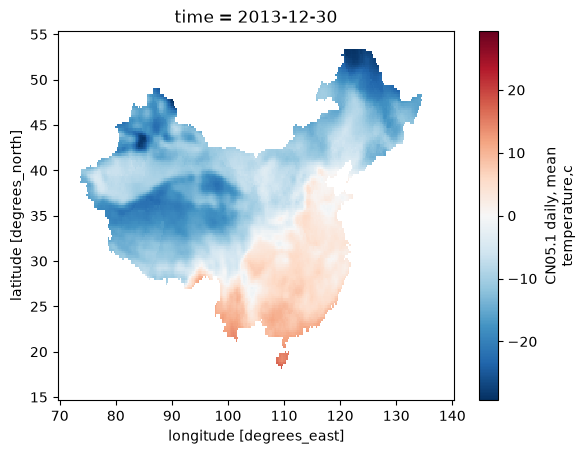

In [9]:
# tm_CN05.tm[19356].plot() # it is fine to use this as at least the data until the end of 2013 are correctly uploaded

In [10]:
N = 19357 # until 30 Dec 2013 (19356 is the 30th Dec 2013, but slice include the start point, and exclude the end point, so we set N to 19357)
tm_CN05_LT = tm_CN05.isel(time=slice(0, N))

In [11]:
# Keep the data of CN05 that are having the same dates in HadGEM dataset
import numpy as np
import pandas as pd
import xarray as xr

# small helper: format numpy.datetime64 to 'YYYY-MM-DD'
def npdate_to_ymd(arr):
    # normalize to days and convert to ISO strings
    return np.datetime_as_string(arr.astype('datetime64[D]'), unit='D')

# small helper: format cftime objects to 'YYYY-MM-DD'
def cftime_to_ymd(arr):
    return np.array([f"{t.year:04d}-{t.month:02d}-{t.day:02d}" for t in arr])

# read (small) time coordinates
t1 = tm_CN05_LT.time.values        # numpy.datetime64[ns]
t2 = tm_HadGEM_LT_1.time.values   # cftime.Datetime360Day (object dtype)

# produce comparable date strings
if np.issubdtype(t1.dtype, np.datetime64):
    t1_dates = npdate_to_ymd(t1)
else:
    # fallback - safe conversion with pandas
    t1_dates = np.array([pd.Timestamp(tt).strftime('%Y-%m-%d') for tt in t1])

# for cftime objects
# (we assume t2 is object array of cftime objects; if not, try fallback)
try:
    t2_dates = cftime_to_ymd(t2)
except Exception:
    # fallback: use pandas (may error for cftime) or str()
    t2_dates = np.array([str(tt)[:10] for tt in t2])

# Diagnostics: sizes and a few sample values
print("len t1:", len(t1), "len t2:", len(t2))
print("sample t1:", t1_dates[:5])
print("sample t2:", t2_dates[:5])

# Find which t1 dates are present in t2
keep_mask = np.isin(t1_dates, t2_dates)
keep_idx = np.nonzero(keep_mask)[0]
print("Number of matching time points:", keep_idx.size)

# Show some examples of unmatched dates (optional)
if keep_idx.size == 0:
    # find first few t1 dates that are not in t2
    missing = t1_dates[~np.isin(t1_dates, t2_dates)]
    print("Example t1 dates not in t2:", missing[:10])

# Select tm_CN05_LT by integer index (memory efficient)
tm_CN05_LT_1 = tm_CN05_LT.isel(time=keep_idx)

# Quick check
print("tm_CN05_LT_1 time length:", tm_CN05_LT_1.sizes['time'])
print("First date kept (t1):", t1_dates[keep_idx[:3]])


len t1: 19357 len t2: 18974
sample t1: ['1961-01-01' '1961-01-02' '1961-01-03' '1961-01-04' '1961-01-05']
sample t2: ['1961-01-01' '1961-01-02' '1961-01-03' '1961-01-04' '1961-01-05']
Number of matching time points: 18974
tm_CN05_LT_1 time length: 18974
First date kept (t1): ['1961-01-01' '1961-01-02' '1961-01-03']


In [12]:
# This is to save the processed observational data (date matching nc file for CN05 data) 358 days per year
tm_CN05_LT_1.to_netcdf("/home/users/weijia_6/Yangtze_code/CN05.1_Tm_1961_2013_daily_025x025.nc")

After mapping the temporal resolurion, we now process the spatial mapping between two datasets (resolution and coverage)

In [13]:
# Map the spatial resolution and coverage for the two dataset

# Open the two datasets (HadGEM & OBS for 1961-2013)
tm_HadGEM_LT_1 = xr.open_dataset("HADGEM_1961_2013_his_358.nc")
tm_CN05_LT_1 = xr.open_dataset("CN05.1_Tm_1961_2013_daily_025x025.nc")

In [14]:
# Regrid the CN05 to HadGEM's resolution (as CN05 has a finer resolition)

# try to correctly regrid the CN05 data
import xarray as xr
import numpy as np
import xesmf as xe
import os

# ---------- user params ----------
obs_file = "/home/users/weijia_6/Yangtze_code/CN05.1_Tm_1961_2013_daily_025x025.nc"
mod_file = "/home/users/weijia_6/Yangtze_code/HADGEM_1961_2013_his_358.nc"
var_obs = "tm"          # observational variable name
var_out = "tm"
out_file = "/home/users/weijia_6/Yangtze_code/tm_CN05_onHadGEMgrid_xesmf_1.nc"
os.makedirs(os.path.dirname(out_file), exist_ok=True)

# ---------- open lazily ----------
obs_ds = xr.open_dataset(obs_file, chunks={"time": 365})
mod_ds = xr.open_dataset(mod_file, chunks={"time": 365})

obs = obs_ds[var_obs]     # dims e.g. time, lat, lon

# ---------- make a validity mask on the obs grid (1 for valid, 0 for NaN) ----------
mask = xr.where(np.isfinite(obs), 1.0, 0.0)

# ---------- create bilinear regridder for field and mask ----------
# Use same regridder for both obs and mask (bilinear)
regridder_var = xe.Regridder(obs_ds, mod_ds, "bilinear", reuse_weights=False)
regridder_mask = regridder_var  # reuse the same bilinear regridder for mask

# ---------- regrid mask and variable ----------
mask_on_target = regridder_mask(mask)     # fractional values (0..1) after bilinear
obs_on_target = regridder_var(obs)

# ---------- threshold fractional coverage and set NaN outside obs domain ----------
# Because bilinear can give small non-zero values for remote cells, set a sensible threshold
thresh = 0.01   # cells with <=1% coverage considered missing
valid = mask_on_target > thresh
obs_on_target_masked = obs_on_target.where(valid)

# ---------- convert to Kelvin (after masking) ----------
obs_on_target_masked = obs_on_target_masked + 273.15
obs_on_target_masked.attrs = obs.attrs.copy()
obs_on_target_masked.attrs['units'] = 'K'

# ---------- sanity checks ----------
print("Mask on target (min,max):", float(mask_on_target.min()), float(mask_on_target.max()))
print("Example valid fraction at time 0 min/max:", float(mask_on_target.isel(time=0).min()), float(mask_on_target.isel(time=0).max()))
print("Non-NaN cells in time 0 after masking:", int(np.sum(np.isfinite(obs_on_target_masked.isel(time=0).values))))

# ---------- save (use compression & chunking) ----------
encoding = {var_out: {"zlib": True, "complevel": 4, "chunksizes": (1, 50, 50)}}
ds_out = obs_on_target_masked.to_dataset(name=var_out)
ds_out.to_netcdf(out_file, encoding=encoding)

# tidy up regridder weight files (portable)
try:
    # new-ish xesmf
    if hasattr(regridder_var, "clean_weight_file"):
        regridder_var.clean_weight_file()
    # older xesmf might have clean_weight_file as clean_weight_file or delete_weight_file:
    elif hasattr(regridder_var, "clean_weights"):
        regridder_var.clean_weights()
    elif hasattr(regridder_var, "del_weight_file"):
        regridder_var.del_weight_file()
    else:
        # as last resort attempt to remove a weights_file attribute if present
        w = getattr(regridder_var, "weights_file", None)
        if w and os.path.exists(w):
            os.remove(w)
except Exception as e:
    print("Warning: unable to clean regridder weight file automatically:", e)


print("Saved masked regridded obs to:", out_file)


Mask on target (min,max): 0.0 1.0000000000000002
Example valid fraction at time 0 min/max: 0.0 1.0000000000000002
Non-NaN cells in time 0 after masking: 1988
Saved masked regridded obs to: /home/users/weijia_6/Yangtze_code/tm_CN05_onHadGEMgrid_xesmf_1.nc


In [16]:
# Verifying

import xarray as xr
a = xr.open_dataset("/home/users/weijia_6/Yangtze_code/tm_CN05_onHadGEMgrid_xesmf_1.nc")
b = xr.open_dataset("/home/users/weijia_6/Yangtze_code/HADGEM_1961_2013_his_358.nc")

print(a.lon.shape, a.lat.shape)
print(b.lon.shape, b.lat.shape)
# quick diffs
print((a['tm'].isel(time=0) - b['tas'].isel(time=0)).mean().values)

(96,) (90,)
(96,) (90,)
-0.7611088


All preprocessing done, now doing the bias correction (correct the HadGEM model data according to the CN05 observational data)

* (quantile mapping) using the "tm_CN05_onHadGEMgrid_xesmf.nc" and the "HADGEM_1961_2013_his_358.nc"

In [18]:
# Check the observational data max, min
import xarray as xr
import numpy as np

obs_file = "/home/users/weijia_6/Yangtze_code/tm_CN05_onHadGEMgrid_xesmf_1.nc"

ds_obs = xr.open_dataset(obs_file)
var = list(ds_obs.data_vars)[0]   # or replace with the actual variable name

print("OBS variable:", var)
print("OBS dims:", ds_obs[var].dims)

print("OBS min/max:", float(ds_obs[var].min()), float(ds_obs[var].max()))


OBS variable: tm
OBS dims: ('time', 'lat', 'lon')
OBS min/max: 228.30787658691406 310.90899658203125


In [20]:
# Check the HadGEM data max, min
mod_file = "/home/users/weijia_6/Yangtze_code/HADGEM_1961_2013_his_358.nc"

ds_mod = xr.open_dataset(mod_file)
var_m = list(ds_mod.data_vars)[0]   # or specify manually

print("MODEL variable:", var_m)
print("MODEL dims:", ds_mod[var_m].dims)

# print("MODEL min/max:", float(ds_mod[var_m].min()), float(ds_mod[var_m].max()))

ds_mod.tas.isel(number=1, time=200).values.min(), ds.tas.isel(number=1, time=200).values.max()


MODEL variable: tas
MODEL dims: ('number', 'time', 'lat', 'lon')


(np.float32(262.864), np.float32(311.6836))

/tmp/ipykernel_629/1918706982.py:19: UserWarning: The specified chunks separate the stored chunks along dimension "number" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  mod_ds = xr.open_dataset(mod_file, chunks={"time": 358, "number": 1})


Obs dims/sizes: ('time', 'lat', 'lon') Frozen({'time': 18974, 'lat': 90, 'lon': 96})
Mod dims/sizes: ('number', 'time', 'lat', 'lon') Frozen({'number': 15, 'time': 18974, 'lat': 90, 'lon': 96})
Number of valid spatial grid cells (obs): 1992
Detected ensemble dim: number
Obs samples: (37721768,)
Model flattened dask shape: (nan,)
Value range (vmin, vmax): 218.92626953125 314.911376953125


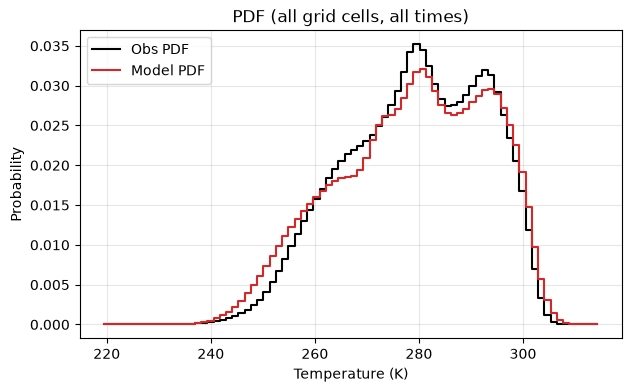

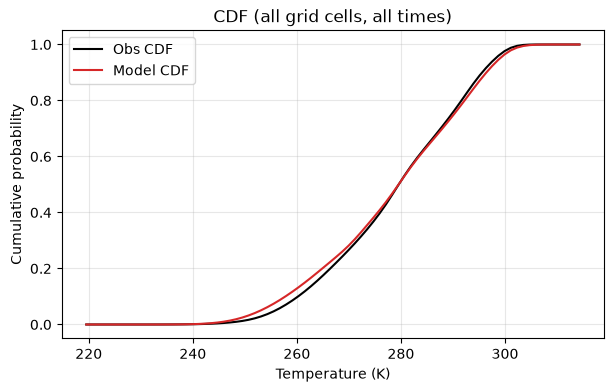

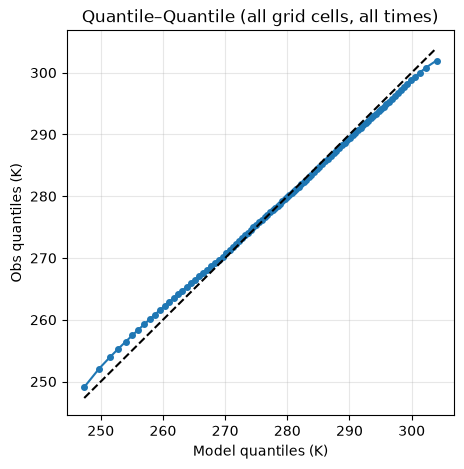

In [21]:
# Compare the distribution of observational CN05 data and simulation HadGEM data
import xarray as xr
import numpy as np
import dask.array as da
import matplotlib.pyplot as plt
import os

# ---------- user params ----------
obs_file = "/home/users/weijia_6/Yangtze_code/tm_CN05_onHadGEMgrid_xesmf_1.nc"
mod_file = "/home/users/weijia_6/Yangtze_code/HADGEM_1961_2013_his_358.nc"
var_obs = "tm"
var_mod = "tas"

outdir = "/home/users/weijia_6/Yangtze_code/bias_correction"
os.makedirs(outdir, exist_ok=True)

# ---------- open with chunking ----------
obs_ds = xr.open_dataset(obs_file, chunks={"time": 358})
mod_ds = xr.open_dataset(mod_file, chunks={"time": 358, "number": 1})

print("Obs dims/sizes:", obs_ds[var_obs].dims, obs_ds[var_obs].sizes)
print("Mod dims/sizes:", mod_ds[var_mod].dims, mod_ds[var_mod].sizes)

da_obs = obs_ds[var_obs]
da_mod = mod_ds[var_mod]

# ---------- spatial validity mask ----------
valid_spatial = da_obs.notnull().any(dim="time")   # lat, lon
n_valid = int(valid_spatial.sum().compute())
print("Number of valid spatial grid cells (obs):", n_valid)
if n_valid == 0:
    raise RuntimeError("No valid spatial cells in observational data.")

# ---------- apply mask ----------
da_obs_masked = da_obs.where(valid_spatial)
da_mod_masked = da_mod.where(valid_spatial)

# detect ensemble dimension in model (if any)
ensemble_dim = None
for d in da_mod_masked.dims:
    if d not in ("time", "lat", "lon"):
        ensemble_dim = d
        break
print("Detected ensemble dim:", ensemble_dim)

# ---------- flatten OBS samples (all time, lat, lon) ----------
obs_flat = da_obs_masked.data.ravel()
obs_flat = obs_flat[~da.isnan(obs_flat)]
# obs_flat = da_obs_masked.stack(z=("time", "lat", "lon"))
# obs_flat = obs_flat.dropna("z")
# obs_samples = obs_flat.values

obs_samples = obs_flat.compute()  # 1D numpy array
print("Obs samples:", obs_samples.shape)

# ---------- flatten MODEL samples (all number, time, lat, lon) ----------
mod_flat = da_mod_masked.data.ravel()
mod_flat = mod_flat[~da.isnan(mod_flat)]

# mod_flat = da_mod_masked.stack(z=("number", "time", "lat", "lon"))
# mod_flat = mod_flat.dropna("z")
# mod_dask = mod_flat.data

mod_dask = mod_flat  # keep as dask for reductions
print("Model flattened dask shape:", mod_dask.shape)

# ---------- determine bin edges ----------
obs_min, obs_max = float(np.nanmin(obs_samples)), float(np.nanmax(obs_samples))
mod_min = float(mod_dask.min().compute())
mod_max = float(mod_dask.max().compute())

vmin = min(obs_min, mod_min)
vmax = max(obs_max, mod_max)
print("Value range (vmin, vmax):", vmin, vmax)

nbins = 80
bins = np.linspace(vmin, vmax, nbins + 1)
bin_centres = 0.5 * (bins[:-1] + bins[1:])

# ---------- histogram for obs ----------
obs_counts, _ = np.histogram(obs_samples, bins=bins, density=False)
obs_pdf = obs_counts / obs_counts.sum()
obs_cdf = np.cumsum(obs_pdf)

# ---------- histogram for model (dask) ----------
mod_counts_da, _ = da.histogram(mod_dask, bins=bins)
mod_counts = mod_counts_da.compute()
mod_pdf = mod_counts / mod_counts.sum()
mod_cdf = np.cumsum(mod_pdf)

# ---------- quantiles ----------
qs = np.linspace(0.01, 0.99, 99)
obs_q = np.quantile(obs_samples, qs)
mod_q = da.percentile(mod_dask, (qs * 100)).compute()

# ---------- PDF plot ----------
plt.figure(figsize=(7, 4))
plt.plot(bin_centres, obs_pdf, drawstyle="steps-mid", label="Obs PDF", color="k")
plt.plot(bin_centres, mod_pdf, drawstyle="steps-mid", label="Model PDF", color="tab:red")
plt.xlabel("Temperature (K)")
plt.ylabel("Probability")
plt.legend()
plt.title("PDF (all grid cells, all times)")
plt.grid(alpha=0.3)
plt.savefig(f"{outdir}/china_temp_pdf.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------- CDF plot ----------
plt.figure(figsize=(7, 4))
plt.plot(bin_centres, obs_cdf, label="Obs CDF", color="k")
plt.plot(bin_centres, mod_cdf, label="Model CDF", color="tab:red")
plt.xlabel("Temperature (K)")
plt.ylabel("Cumulative probability")
plt.legend()
plt.title("CDF (all grid cells, all times)")
plt.grid(alpha=0.3)
plt.savefig(f"{outdir}/china_temp_cdf.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------- QQ plot ----------
plt.figure(figsize=(5, 5))
plt.plot(mod_q, obs_q, "o-", markersize=4)
mn = min(mod_q.min(), obs_q.min())
mx = max(mod_q.max(), obs_q.max())
plt.plot([mn, mx], [mn, mx], "k--")
plt.xlabel("Model quantiles (K)")
plt.ylabel("Obs quantiles (K)")
plt.title("Quantile–Quantile (all grid cells, all times)")
plt.grid(alpha=0.3)
plt.savefig(f"{outdir}/china_temp_QQ.png", dpi=300, bbox_inches="tight")
plt.show()


In [2]:
# Bias correct the 1961-2013 HadGEM data, save the corrected data for plotting, and the store the per grid mapping
import numpy as np
import xarray as xr
from scipy.interpolate import interp1d
import os

# ---------------- user settings ----------------
obs_file = "/home/users/weijia_6/Yangtze_code/tm_CN05_onHadGEMgrid_xesmf_1.nc"
mod_file = "/home/users/weijia_6/Yangtze_code/HADGEM_1961_2013_his_358.nc"
var_obs = "tm"
var_mod = "tas"

out_bc_file = "/home/users/weijia_6/Yangtze_code/HADGEM_1961_2013_his_qm_pergrid.nc"
out_map_file = "/home/users/weijia_6/Yangtze_code/qm_mapping_pergrid.nc"

nbins = 200   # number of bins for each grid cell mapping

# ---------------- load datasets lazily ----------------
obs_ds = xr.open_dataset(obs_file)
mod_ds = xr.open_dataset(mod_file)

da_obs = obs_ds[var_obs]
da_mod = mod_ds[var_mod]

lat = da_obs.lat
lon = da_obs.lon

# ---------------- create output datasets ----------------
# bias-corrected model
mod_bc = xr.Dataset(
    {var_mod: (da_mod.dims, np.full(da_mod.shape, np.nan, dtype=np.float32))},
    coords=mod_ds.coords
)

# mapping storage: (lat, lon, nbins)
qm_bin_centres = xr.DataArray(
    np.full((len(lat), len(lon), nbins), np.nan, dtype=np.float32),
    dims=("lat", "lon", "bins"),
    coords={"lat": lat, "lon": lon, "bins": np.arange(nbins)}
)

qm_model_to_obs = xr.DataArray(
    np.full((len(lat), len(lon), nbins), np.nan, dtype=np.float32),
    dims=("lat", "lon", "bins"),
    coords={"lat": lat, "lon": lon, "bins": np.arange(nbins)}
)

# ---------------- loop over grid cells ----------------
for i in range(len(lat)):
    for j in range(len(lon)):

        # extract obs + model time series at this grid cell
        obs_ts = da_obs[:, i, j].values
        mod_ts = da_mod[:, :, i, j].values if "number" in da_mod.dims else da_mod[:, i, j].values

        # skip if obs is all NaN (outside China)
        if np.all(np.isnan(obs_ts)):
            continue

        # drop NaNs
        obs_valid = obs_ts[np.isfinite(obs_ts)]
        mod_valid = mod_ts[np.isfinite(mod_ts)]

        if len(obs_valid) < 50:
            continue

        # ---------------- build QM mapping for this grid cell ----------------
        vmin = min(obs_valid.min(), mod_valid.min())
        vmax = max(obs_valid.max(), mod_valid.max())

        bins = np.linspace(vmin, vmax, nbins + 1)
        centres = 0.5 * (bins[:-1] + bins[1:])

        # obs CDF
        obs_counts, _ = np.histogram(obs_valid, bins=bins)
        obs_pdf = obs_counts / obs_counts.sum()
        obs_cdf = np.cumsum(obs_pdf)
        obs_cdf = np.maximum.accumulate(obs_cdf)
        obs_cdf /= obs_cdf[-1]

        # model CDF
        mod_counts, _ = np.histogram(mod_valid, bins=bins)
        mod_pdf = mod_counts / mod_counts.sum()
        mod_cdf = np.cumsum(mod_pdf)
        mod_cdf = np.maximum.accumulate(mod_cdf)
        mod_cdf /= mod_cdf[-1]

        # build interpolators
        mod_to_p = interp1d(
            centres, mod_cdf,
            bounds_error=False, fill_value=(0, 1), assume_sorted=True
        )
        p_to_obs = interp1d(
            obs_cdf, centres,
            bounds_error=False,
            fill_value=(centres[0], centres[-1]), assume_sorted=True
        )

        # ---------------- apply QM to full model time series ----------------
        mod_flat = mod_ts.ravel()
        p = mod_to_p(mod_flat)
        mapped = p_to_obs(p)
        mapped = mapped.reshape(mod_ts.shape)

        # ---------------- write corrected values ----------------
        mod_bc[var_mod][:, :, i, j] = mapped

        # ---------------- store mapping for this grid cell ----------------
        qm_bin_centres[i, j, :] = centres
        qm_model_to_obs[i, j, :] = p_to_obs(mod_to_p(centres))

    print(f"Completed latitude {i+1}/{len(lat)}")

# ---------------- save outputs ----------------
mod_bc.to_netcdf(out_bc_file)
print("Saved bias-corrected HadGEM:", out_bc_file)

qm_map_ds = xr.Dataset({
    "qm_bin_centres": qm_bin_centres,
    "qm_model_to_obs": qm_model_to_obs
})
qm_map_ds.to_netcdf(out_map_file)
print("Saved per-grid-cell QM mapping:", out_map_file)



Completed latitude 1/90
Completed latitude 2/90
Completed latitude 3/90
Completed latitude 4/90
Completed latitude 5/90
Completed latitude 6/90
Completed latitude 7/90
Completed latitude 8/90
Completed latitude 9/90
Completed latitude 10/90
Completed latitude 11/90
Completed latitude 12/90
Completed latitude 13/90
Completed latitude 14/90
Completed latitude 15/90


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:482: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


Completed latitude 16/90
Completed latitude 17/90
Completed latitude 18/90
Completed latitude 19/90
Completed latitude 20/90
Completed latitude 21/90
Completed latitude 22/90
Completed latitude 23/90
Completed latitude 24/90
Completed latitude 25/90
Completed latitude 26/90
Completed latitude 27/90
Completed latitude 28/90
Completed latitude 29/90
Completed latitude 30/90
Completed latitude 31/90
Completed latitude 32/90
Completed latitude 33/90
Completed latitude 34/90
Completed latitude 35/90
Completed latitude 36/90
Completed latitude 37/90
Completed latitude 38/90
Completed latitude 39/90
Completed latitude 40/90
Completed latitude 41/90
Completed latitude 42/90
Completed latitude 43/90
Completed latitude 44/90
Completed latitude 45/90
Completed latitude 46/90
Completed latitude 47/90
Completed latitude 48/90
Completed latitude 49/90
Completed latitude 50/90
Completed latitude 51/90
Completed latitude 52/90
Completed latitude 53/90
Completed latitude 54/90
Completed latitude 55/90


Obs dims/sizes: ('time', 'lat', 'lon') Frozen({'time': 18974, 'lat': 90, 'lon': 96})
Mod dims/sizes: ('number', 'time', 'lat', 'lon') Frozen({'number': 15, 'time': 18974, 'lat': 90, 'lon': 96})
Number of valid spatial grid cells (obs): 1992
Detected ensemble dim: number
Obs samples: (37721768,)
Model flattened dask shape: (nan,)
Value range (vmin, vmax): 228.30787658691406 310.90899658203125


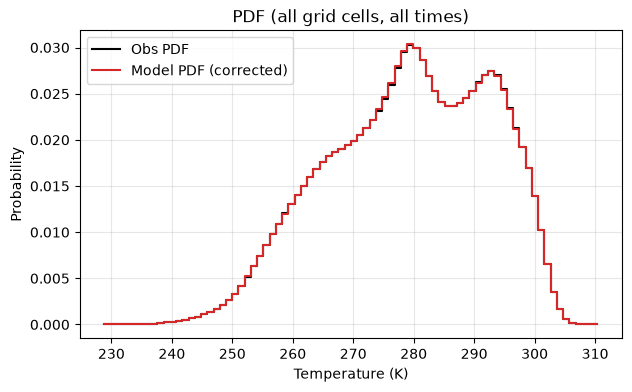

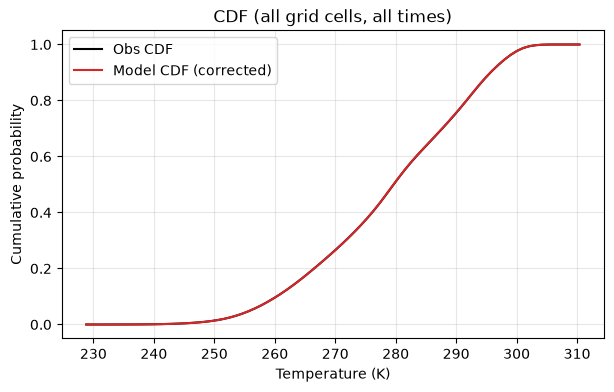

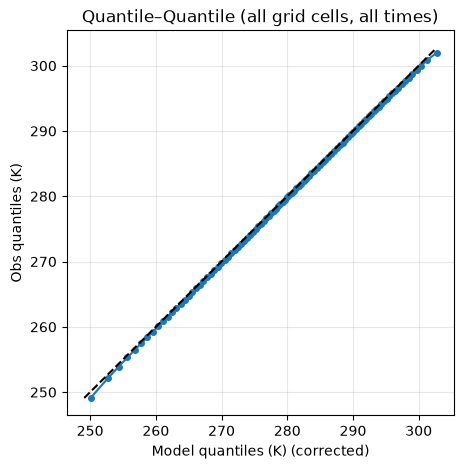

In [4]:
# Compare the observation and the bias corrected hadGEM model
# Compare the observational data with corrected data

# Correct and memory-safe version to compare the distribution of observational CN05 data and simulation HadGEM data
import xarray as xr
import numpy as np
import dask.array as da
import matplotlib.pyplot as plt
import os

# ---------- user params ----------
obs_file = "/home/users/weijia_6/Yangtze_code/tm_CN05_onHadGEMgrid_xesmf_1.nc"
mod_file = "/home/users/weijia_6/Yangtze_code/HADGEM_1961_2013_his_qm_pergrid.nc"
var_obs = "tm"
var_mod = "tas"

outdir = "/home/users/weijia_6/Yangtze_code/bias_correction"
os.makedirs(outdir, exist_ok=True)

# ---------- open with chunking ----------
obs_ds = xr.open_dataset(obs_file, chunks={"time": 358})
mod_ds = xr.open_dataset(mod_file, chunks={"time": 358, "number": 1})

print("Obs dims/sizes:", obs_ds[var_obs].dims, obs_ds[var_obs].sizes)
print("Mod dims/sizes:", mod_ds[var_mod].dims, mod_ds[var_mod].sizes)

da_obs = obs_ds[var_obs]
da_mod = mod_ds[var_mod]

# ---------- spatial validity mask ----------
valid_spatial = da_obs.notnull().any(dim="time")   # lat, lon
n_valid = int(valid_spatial.sum().compute())
print("Number of valid spatial grid cells (obs):", n_valid)
if n_valid == 0:
    raise RuntimeError("No valid spatial cells in observational data.")

# ---------- apply mask ----------
da_obs_masked = da_obs.where(valid_spatial)
da_mod_masked = da_mod.where(valid_spatial)

# detect ensemble dimension in model (if any)
ensemble_dim = None
for d in da_mod_masked.dims:
    if d not in ("time", "lat", "lon"):
        ensemble_dim = d
        break
print("Detected ensemble dim:", ensemble_dim)

# ---------- flatten OBS samples (all time, lat, lon) ----------
obs_flat = da_obs_masked.data.ravel()
obs_flat = obs_flat[~da.isnan(obs_flat)]
# obs_flat = da_obs_masked.stack(z=("time", "lat", "lon"))
# obs_flat = obs_flat.dropna("z")
# obs_samples = obs_flat.values

obs_samples = obs_flat.compute()  # 1D numpy array
print("Obs samples:", obs_samples.shape)

# ---------- flatten MODEL samples (all number, time, lat, lon) ----------
mod_flat = da_mod_masked.data.ravel()
mod_flat = mod_flat[~da.isnan(mod_flat)]

# mod_flat = da_mod_masked.stack(z=("number", "time", "lat", "lon"))
# mod_flat = mod_flat.dropna("z")
# mod_dask = mod_flat.data

mod_dask = mod_flat  # keep as dask for reductions
print("Model flattened dask shape:", mod_dask.shape)

# ---------- determine bin edges ----------
obs_min, obs_max = float(np.nanmin(obs_samples)), float(np.nanmax(obs_samples))
mod_min = float(mod_dask.min().compute())
mod_max = float(mod_dask.max().compute())

vmin = min(obs_min, mod_min)
vmax = max(obs_max, mod_max)
print("Value range (vmin, vmax):", vmin, vmax)

nbins = 80
bins = np.linspace(vmin, vmax, nbins + 1)
bin_centres = 0.5 * (bins[:-1] + bins[1:])

# ---------- histogram for obs ----------
obs_counts, _ = np.histogram(obs_samples, bins=bins, density=False)
obs_pdf = obs_counts / obs_counts.sum()
obs_cdf = np.cumsum(obs_pdf)

# ---------- histogram for model (dask) ----------
mod_counts_da, _ = da.histogram(mod_dask, bins=bins)
mod_counts = mod_counts_da.compute()
mod_pdf = mod_counts / mod_counts.sum()
mod_cdf = np.cumsum(mod_pdf)

# ---------- quantiles ----------
qs = np.linspace(0.01, 0.99, 99)
obs_q = np.quantile(obs_samples, qs)
mod_q = da.percentile(mod_dask, (qs * 100)).compute()

# ---------- PDF plot ----------
plt.figure(figsize=(7, 4))
plt.plot(bin_centres, obs_pdf, drawstyle="steps-mid", label="Obs PDF", color="k")
plt.plot(bin_centres, mod_pdf, drawstyle="steps-mid", label="Model PDF (corrected)", color="tab:red")
plt.xlabel("Temperature (K)")
plt.ylabel("Probability")
plt.legend()
plt.title("PDF (all grid cells, all times)")
plt.grid(alpha=0.3)
plt.savefig(f"{outdir}/pdf_after_qm.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------- CDF plot ----------
plt.figure(figsize=(7, 4))
plt.plot(bin_centres, obs_cdf, label="Obs CDF", color="k")
plt.plot(bin_centres, mod_cdf, label="Model CDF (corrected)", color="tab:red")
plt.xlabel("Temperature (K)")
plt.ylabel("Cumulative probability")
plt.legend()
plt.title("CDF (all grid cells, all times)")
plt.grid(alpha=0.3)
plt.savefig(f"{outdir}/cdf_after_qm.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------- QQ plot ----------
plt.figure(figsize=(5, 5))
plt.plot(mod_q, obs_q, "o-", markersize=4)
mn = min(mod_q.min(), obs_q.min())
mx = max(mod_q.max(), obs_q.max())
plt.plot([mn, mx], [mn, mx], "k--")
plt.xlabel("Model quantiles (K) (corrected)")
plt.ylabel("Obs quantiles (K)")
plt.title("Quantile–Quantile (all grid cells, all times)")
plt.grid(alpha=0.3)
plt.savefig(f"{outdir}/qq_after_qm.png", dpi=300, bbox_inches="tight")
plt.show()


Now, the bias corrected HadGEM long term data and the bias correction function is saved. We will then apply the bias correction function to the 525 large ensemble HadGEM factual and counterfactual dataset

In [2]:
# Check previous code spatial range

import xarray as xr
import numpy as np

china_file = "/home/users/weijia_6/HADGEM_2022_factual_JunAug.nc"

ds = xr.open_dataset(china_file)

print(ds)

# Try common coordinate names
coord_pairs = [
    ("lat", "lon"),
    ("latitude", "longitude"),
]

for lat_name, lon_name in coord_pairs:
    if lat_name in ds.coords and lon_name in ds.coords:
        lat = ds[lat_name]
        lon = ds[lon_name]

        print(f"\nUsing coordinates: {lat_name}, {lon_name}")
        print(f"{lat_name} min/max: {float(lat.min()):.4f}, {float(lat.max()):.4f}")
        print(f"{lon_name} min/max: {float(lon.min()):.4f}, {float(lon.max()):.4f}")

        # If latitude is descending, print that too
        print(f"{lat_name} is ascending: {bool(np.all(np.diff(lat.values) > 0))}")
        print(f"{lon_name} is ascending: {bool(np.all(np.diff(lon.values) > 0))}")
        break
else:
    raise KeyError("Could not find latitude/longitude coordinate names in the dataset.")

<xarray.Dataset> Size: 2GB
Dimensions:    (number: 525, latitude: 90, longitude: 108, time: 90)
Coordinates:
  * number     (number) int64 4kB 1 2 3 4 5 6 7 ... 519 520 521 522 523 524 525
  * latitude   (latitude) float32 360B 10.28 10.83 11.39 ... 58.61 59.17 59.72
  * longitude  (longitude) float32 432B 60.42 61.25 62.08 ... 147.9 148.8 149.6
  * time       (time) object 720B 2022-06-01 12:00:00 ... 2022-08-30 12:00:00
Data variables:
    tas        (number, time, latitude, longitude) float32 2GB ...

Using coordinates: latitude, longitude
latitude min/max: 10.2778, 59.7222
longitude min/max: 60.4167, 149.5833
latitude is ascending: True
longitude is ascending: True


In [3]:
"""
Build one NetCDF with all HadGEM3-A-N216 2022 factual ensembles,
restricted to the China spatial range from the previous dataset.

Months: Jun–Aug 2022 (360-day calendar, 30 days/month)
Ensembles: r001–r105 × p1–p5  → number = 1..525
"""

import os
from glob import glob
from itertools import product

import numpy as np
import xarray as xr

# ---------------- USER SETTINGS ----------------
base_dir = "/gws/ssde/j25a/cssp_china/wp1/HadGEM3-A-N216/historicalExt/tas/day" # global data, not only china region
months = ["202206", "202207", "202208"]
out_file = "/home/users/weijia_6/Yangtze_code/HADGEM_2022_factual_JunAug.nc"
varname = "tas"

# China spatial range from your previous dataset
lat_min, lat_max = 10.2778, 59.7222
lon_min, lon_max = 60.4167, 149.5833

# chunking (HadGEM 360-day calendar)
read_chunks = {"time": 30}   # monthly chunks
chunk_number = 1              # one ensemble per chunk

# ensemble ranges
r_values = range(1, 106)   # r001–r105
p_values = range(1, 6)     # p1–p5

# require all 3 months for an ensemble
require_all_months = True
# ------------------------------------------------


def find_month_file(r, p, ym, base_dir):
    """
    Find a monthly file for one ensemble member.
    Uses recursive glob so it works whether files are in base_dir
    or in subfolders.
    """
    r_str = f"{r:03d}"
    p_str = f"{p}"
    pattern = os.path.join(
        base_dir,
        "**",
        f"*r{r_str}i1p{p_str}*{ym}*.nc"
    )
    matches = sorted(glob(pattern, recursive=True))
    return matches[0] if matches else None


def detect_lat_lon_names(ds):
    """
    Detect latitude/longitude coordinate names.
    Handles common cases: latitude/longitude or lat/lon.
    """
    if "latitude" in ds.coords and "longitude" in ds.coords:
        return "latitude", "longitude"
    if "lat" in ds.coords and "lon" in ds.coords:
        return "lat", "lon"
    raise KeyError(
        "Could not find latitude/longitude coordinates. "
        "Expected either ('latitude', 'longitude') or ('lat', 'lon')."
    )


def subset_region(da, lat_name, lon_name, lat_min, lat_max, lon_min, lon_max):
    """
    Subset a DataArray to the requested lat/lon box.
    Works for ascending or descending coordinates.
    """
    lat_vals = da[lat_name].values
    lon_vals = da[lon_name].values

    # Latitude slice
    if lat_vals[0] < lat_vals[-1]:
        lat_slice = slice(lat_min, lat_max)
    else:
        lat_slice = slice(lat_max, lat_min)

    # Longitude slice
    if lon_vals[0] < lon_vals[-1]:
        lon_slice = slice(lon_min, lon_max)
    else:
        lon_slice = slice(lon_max, lon_min)

    da = da.sel({lat_name: lat_slice, lon_name: lon_slice})
    return da


# -------- load ensembles lazily -----------------
ens_list = []
missing_report = []

for r, p in product(r_values, p_values):
    ensemble_num = (r - 1) * 5 + p

    month_files = [find_month_file(r, p, ym, base_dir) for ym in months]
    missing = [ym for ym, f in zip(months, month_files) if f is None]

    if missing and require_all_months:
        print(
            f"Skipping ensemble {ensemble_num:03d} "
            f"(r{r:03d} p{p}) – missing {missing}"
        )
        missing_report.append((ensemble_num, r, p, missing))
        continue

    files = [f for f in month_files if f is not None]

    try:
        ds = xr.open_mfdataset(
            files,
            combine="by_coords",
            parallel=False,
            chunks=read_chunks,
        )

        if varname not in ds:
            raise KeyError(f"Variable '{varname}' not found in {files[0]}")

        da = ds[varname]

        # defensive time slice (360-day calendar)
        da = da.sel(time=slice("2022-06-01", "2022-08-30"))

        # detect coordinate names
        lat_name, lon_name = detect_lat_lon_names(da)

        # subset to the China region only
        da = subset_region(
            da,
            lat_name=lat_name,
            lon_name=lon_name,
            lat_min=lat_min,
            lat_max=lat_max,
            lon_min=lon_min,
            lon_max=lon_max,
        )

        # add ensemble dimension
        da = da.expand_dims(number=[ensemble_num])

        ens_list.append(da)

    except Exception as e:
        print(f"ERROR loading ensemble {ensemble_num:03d}: {e}")
        missing_report.append((ensemble_num, r, p, str(e)))

print(f"\nLoaded ensembles: {len(ens_list)}")
print(f"Skipped ensembles: {len(missing_report)}")

if len(ens_list) == 0:
    raise RuntimeError("No ensembles loaded. Check file names, paths, and coordinate names.")


# -------- concatenate along 'number' -------------
print("\nConcatenating ensembles...")
combined = xr.concat(ens_list, dim="number")
combined = combined.sel(number=np.sort(combined["number"].values))

print("Combined dims/sizes:")
print(combined.dims)
print({d: combined.sizes[d] for d in combined.dims})

# -------- prepare NetCDF encoding ----------------
# detect spatial dims (latitude/longitude or lat/lon)
spatial_dims = [d for d in combined.dims if d not in ("number", "time")]

if len(spatial_dims) != 2:
    raise RuntimeError(
        f"Expected 2 spatial dimensions, found {spatial_dims}. "
        "Please check the dataset dimension names."
    )

lat_dim, lon_dim = spatial_dims
lat_size = combined.sizes[lat_dim]
lon_size = combined.sizes[lon_dim]

encoding = {
    varname: {
        "zlib": True,
        "complevel": 4,
        "chunksizes": (
            chunk_number,   # number
            30,             # time
            lat_size,
            lon_size,
        ),
    }
}

# -------- write output ---------------------------
os.makedirs(os.path.dirname(out_file), exist_ok=True)

print("\nWriting output to:")
print(out_file)

combined.to_dataset(name=varname).to_netcdf(
    out_file,
    format="NETCDF4",
    encoding=encoding,
    compute=True,
)

print("\n✅ DONE")
print(f"Final ensemble count: {combined.sizes['number']}")
print(f"Latitude range in output: {float(combined[lat_dim].min()):.4f} to {float(combined[lat_dim].max()):.4f}")
print(f"Longitude range in output: {float(combined[lon_dim].min()):.4f} to {float(combined[lon_dim].max()):.4f}")

if missing_report:
    print("\nSome ensembles were skipped (examples):")
    for item in missing_report[:10]:
        print(item)


Loaded ensembles: 525
Skipped ensembles: 0

Concatenating ensembles...
Combined dims/sizes:
('number', 'time', 'latitude', 'longitude')
{'number': 525, 'time': 90, 'latitude': 88, 'longitude': 106}

Writing output to:
/home/users/weijia_6/Yangtze_code/HADGEM_2022_factual_JunAug.nc

✅ DONE
Final ensemble count: 525
Latitude range in output: 10.8333 to 59.1667
Longitude range in output: 61.2500 to 148.7500


Bias correct the 525 f/cf JJA temp data

In [5]:
"""
Build one NetCDF with all HadGEM3-A-N216 2022 counterfactual ensembles,
restricted to the China spatial range from the previous dataset.

Months: Jun–Aug 2022 (360-day calendar, 30 days/month)
Ensembles: r001–r105 × p1–p5  → number = 1..525
"""

import os
from glob import glob
from itertools import product

import numpy as np
import xarray as xr

# ---------------- USER SETTINGS ----------------
base_dir = "/gws/ssde/j25a/cssp_china/wp1/HadGEM3-A-N216/historicalNatExt/tas/day"
months = ["202206", "202207", "202208"]
out_file = "/home/users/weijia_6/Yangtze_code/HADGEM_2022_counterfactual_JunAug.nc"
varname = "tas"

# China spatial range from your previous dataset
lat_min, lat_max = 10.2778, 59.7222
lon_min, lon_max = 60.4167, 149.5833

# chunking (HadGEM 360-day calendar)
read_chunks = {"time": 30}
chunk_number = 1

# ensemble ranges
r_values = range(1, 106)   # r001–r105
p_values = range(1, 6)     # p1–p5

# require all 3 months for an ensemble
require_all_months = True
# ------------------------------------------------


def find_month_file(r, p, ym, base_dir):
    """
    Find a monthly file for one ensemble member.
    Uses recursive glob so it works whether files are directly in base_dir
    or inside subfolders.
    """
    r_str = f"{r:03d}"
    p_str = f"{p}"
    pattern = os.path.join(
        base_dir,
        "**",
        f"*r{r_str}i1p{p_str}*{ym}*.nc"
    )
    matches = sorted(glob(pattern, recursive=True))
    return matches[0] if matches else None


def detect_lat_lon_names(ds):
    """
    Detect latitude/longitude coordinate names.
    Handles common cases: latitude/longitude or lat/lon.
    """
    if "latitude" in ds.coords and "longitude" in ds.coords:
        return "latitude", "longitude"
    if "lat" in ds.coords and "lon" in ds.coords:
        return "lat", "lon"
    raise KeyError(
        "Could not find latitude/longitude coordinates. "
        "Expected either ('latitude', 'longitude') or ('lat', 'lon')."
    )


def subset_region(da, lat_name, lon_name, lat_min, lat_max, lon_min, lon_max):
    """
    Subset a DataArray to the requested lat/lon box.
    Works for ascending or descending coordinates.
    """
    lat_vals = da[lat_name].values
    lon_vals = da[lon_name].values

    if lat_vals[0] < lat_vals[-1]:
        lat_slice = slice(lat_min, lat_max)
    else:
        lat_slice = slice(lat_max, lat_min)

    if lon_vals[0] < lon_vals[-1]:
        lon_slice = slice(lon_min, lon_max)
    else:
        lon_slice = slice(lon_max, lon_min)

    return da.sel({lat_name: lat_slice, lon_name: lon_slice})


# -------- load ensembles lazily -----------------
ens_list = []
missing_report = []

for r, p in product(r_values, p_values):
    ensemble_num = (r - 1) * 5 + p

    month_files = [find_month_file(r, p, ym, base_dir) for ym in months]
    missing = [ym for ym, f in zip(months, month_files) if f is None]

    if missing and require_all_months:
        print(
            f"Skipping ensemble {ensemble_num:03d} "
            f"(r{r:03d} p{p}) – missing {missing}"
        )
        missing_report.append((ensemble_num, r, p, missing))
        continue

    files = [f for f in month_files if f is not None]

    try:
        ds = xr.open_mfdataset(
            files,
            combine="by_coords",
            parallel=False,
            chunks=read_chunks
        )

        if varname not in ds:
            raise KeyError(f"Variable '{varname}' not found in {files[0]}")

        da = ds[varname]

        # Defensive time slice (360-day calendar)
        da = da.sel(time=slice("2022-06-01", "2022-08-30"))

        # Detect coordinate names
        lat_name, lon_name = detect_lat_lon_names(da)

        # Subset to China region only
        da = subset_region(
            da,
            lat_name=lat_name,
            lon_name=lon_name,
            lat_min=lat_min,
            lat_max=lat_max,
            lon_min=lon_min,
            lon_max=lon_max,
        )

        # Add ensemble dimension
        da = da.expand_dims(number=[ensemble_num])

        ens_list.append(da)

    except Exception as e:
        print(f"ERROR loading ensemble {ensemble_num:03d}: {e}")
        missing_report.append((ensemble_num, r, p, str(e)))

print(f"\nLoaded ensembles: {len(ens_list)}")
print(f"Skipped ensembles: {len(missing_report)}")

if len(ens_list) == 0:
    raise RuntimeError(
        "No ensembles loaded. Check file names, paths, and coordinate names."
    )


# -------- concatenate along 'number' -------------
print("\nConcatenating ensembles...")
combined = xr.concat(ens_list, dim="number")
combined = combined.sel(number=np.sort(combined["number"].values))

print("Combined dims/sizes:")
print(combined.dims)
print({d: combined.sizes[d] for d in combined.dims})


# -------- prepare NetCDF encoding ----------------
spatial_dims = [d for d in combined.dims if d not in ("number", "time")]

if len(spatial_dims) != 2:
    raise RuntimeError(
        f"Expected 2 spatial dimensions, found {spatial_dims}. "
        "Please check the dataset dimension names."
    )

lat_dim, lon_dim = spatial_dims
lat_size = combined.sizes[lat_dim]
lon_size = combined.sizes[lon_dim]

encoding = {
    varname: {
        "zlib": True,
        "complevel": 4,
        "chunksizes": (
            chunk_number,
            30,
            lat_size,
            lon_size
        )
    }
}

# -------- write output ---------------------------
os.makedirs(os.path.dirname(out_file), exist_ok=True)

print("\nWriting output to:")
print(out_file)

combined.to_dataset(name=varname).to_netcdf(
    out_file,
    format="NETCDF4",
    encoding=encoding,
    compute=True
)

print("\n✅ DONE")
print(f"Final ensemble count: {combined.sizes['number']}")
print(f"Latitude range in output: {float(combined[lat_dim].min()):.4f} to {float(combined[lat_dim].max()):.4f}")
print(f"Longitude range in output: {float(combined[lon_dim].min()):.4f} to {float(combined[lon_dim].max()):.4f}")

if missing_report:
    print("\nSome ensembles were skipped (examples):")
    for item in missing_report[:10]:
        print(item)


Loaded ensembles: 525
Skipped ensembles: 0

Concatenating ensembles...
Combined dims/sizes:
('number', 'time', 'latitude', 'longitude')
{'number': 525, 'time': 90, 'latitude': 88, 'longitude': 106}

Writing output to:
/home/users/weijia_6/Yangtze_code/HADGEM_2022_counterfactual_JunAug.nc

✅ DONE
Final ensemble count: 525
Latitude range in output: 10.8333 to 59.1667
Longitude range in output: 61.2500 to 148.7500


Bias correct the 2022 factual and counterfactual data

In [2]:
# Bias correct the 2022 factual and counterfactual data

import numpy as np
import xarray as xr
from scipy.interpolate import interp1d
import os

# -------------------------------------------------
# Paths and settings
# -------------------------------------------------
factual_path   = "/home/users/weijia_6/Yangtze_code/HADGEM_2022_factual_JunAug.nc"
counter_path   = "/home/users/weijia_6/Yangtze_code/HADGEM_2022_counterfactual_JunAug.nc"
mapping_path   = "/home/users/weijia_6/Yangtze_code/qm_mapping_pergrid.nc"

var_mod = "tas"  # adjust if different

out_factual_bc = "/home/users/weijia_6/Yangtze_code/HADGEM_2022_factual_JunAug_qm_pergrid.nc"
out_counter_bc = "/home/users/weijia_6/Yangtze_code/HADGEM_2022_counterfactual_JunAug_qm_pergrid.nc"

# -------------------------------------------------
# Load mapping
# -------------------------------------------------
map_ds = xr.open_dataset(mapping_path)
qm_bin_centres   = map_ds["qm_bin_centres"]   # (lat, lon, bins)
qm_model_to_obs  = map_ds["qm_model_to_obs"]  # (lat, lon, bins)

lat = qm_bin_centres["lat"]
lon = qm_bin_centres["lon"]
nbins = qm_bin_centres.sizes["bins"]

# -------------------------------------------------
# Helper: apply mapping to one dataset
# -------------------------------------------------
def apply_qm_to_dataset(in_path, out_path):
    ds = xr.open_dataset(in_path)
    da = ds[var_mod]  # expect (number, time, lat, lon) or (time, lat, lon)

    # create output dataset with same coords/dims
    bc = xr.Dataset(
        {var_mod: (da.dims, np.full(da.shape, np.nan, dtype=np.float32))},
        coords=ds.coords
    )

    has_ens = "number" in da.dims

    for i in range(len(lat)):
        for j in range(len(lon)):

            # mapping for this grid cell
            centres = qm_bin_centres.isel(lat=i, lon=j).values
            mapped_vals = qm_model_to_obs.isel(lat=i, lon=j).values

            # if mapping is all NaN (e.g. outside China), skip
            if np.all(np.isnan(centres)) or np.all(np.isnan(mapped_vals)):
                continue

            # build interpolator: model value -> corrected value
            f_map = interp1d(
                centres,
                mapped_vals,
                bounds_error=False,
                fill_value=(mapped_vals[0], mapped_vals[-1]),
                assume_sorted=True,
            )

            # extract model data at this grid cell
            if has_ens:
                mod_ts = da[:, :, i, j].values  # (number, time)
            else:
                mod_ts = da[:, i, j].values     # (time,)

            # if all NaN, skip
            if np.all(np.isnan(mod_ts)):
                continue

            flat = mod_ts.ravel()
            mask = np.isfinite(flat)

            corrected = np.full_like(flat, np.nan, dtype=np.float32)
            corrected[mask] = f_map(flat[mask])
            corrected = corrected.reshape(mod_ts.shape)

            # write back
            if has_ens:
                bc[var_mod][:, :, i, j] = corrected
            else:
                bc[var_mod][:, i, j] = corrected

        print(f"{os.path.basename(in_path)}: completed latitude {i+1}/{len(lat)}")

    # save
    encoding = {var_mod: {"dtype": "float32", "zlib": True, "complevel": 4}}
    bc.to_netcdf(out_path, encoding=encoding)
    print("Saved bias-corrected file:", out_path)


# -------------------------------------------------
# Apply mapping to factual and counterfactual
# -------------------------------------------------
apply_qm_to_dataset(factual_path,  out_factual_bc)
apply_qm_to_dataset(counter_path,  out_counter_bc)



HADGEM_2022_factual_JunAug.nc: completed latitude 1/90
HADGEM_2022_factual_JunAug.nc: completed latitude 2/90
HADGEM_2022_factual_JunAug.nc: completed latitude 3/90
HADGEM_2022_factual_JunAug.nc: completed latitude 4/90
HADGEM_2022_factual_JunAug.nc: completed latitude 5/90
HADGEM_2022_factual_JunAug.nc: completed latitude 6/90
HADGEM_2022_factual_JunAug.nc: completed latitude 7/90
HADGEM_2022_factual_JunAug.nc: completed latitude 8/90
HADGEM_2022_factual_JunAug.nc: completed latitude 9/90
HADGEM_2022_factual_JunAug.nc: completed latitude 10/90
HADGEM_2022_factual_JunAug.nc: completed latitude 11/90
HADGEM_2022_factual_JunAug.nc: completed latitude 12/90
HADGEM_2022_factual_JunAug.nc: completed latitude 13/90
HADGEM_2022_factual_JunAug.nc: completed latitude 14/90
HADGEM_2022_factual_JunAug.nc: completed latitude 15/90
HADGEM_2022_factual_JunAug.nc: completed latitude 16/90
HADGEM_2022_factual_JunAug.nc: completed latitude 17/90
HADGEM_2022_factual_JunAug.nc: completed latitude 18/90
H

('number', 'time', 'latitude', 'longitude')
Frozen({'number': 525, 'time': 90, 'latitude': 88, 'longitude': 106})
270.5578 302.61606


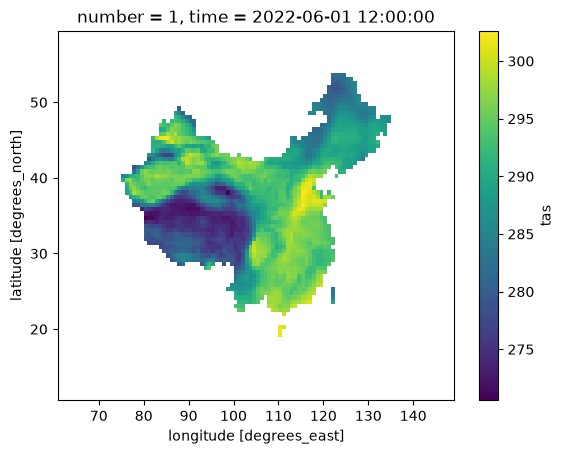

In [3]:
# Dataset check
import xarray as xr

ds_counterfactual_qm = xr.open_dataset("/home/users/weijia_6/Yangtze_code/HADGEM_2022_factual_JunAug_qm_pergrid.nc", chunks={})
print(ds_counterfactual_qm["tas"].dims)
print(ds_counterfactual_qm["tas"].sizes)

# spot check
print(ds_counterfactual_qm["tas"].isel(number=0, time=0).min().values,
      ds_counterfactual_qm["tas"].isel(number=0, time=0).max().values)

ds_counterfactual_qm.tas[0,0].plot()

('number', 'time', 'latitude', 'longitude')
Frozen({'number': 525, 'time': 90, 'latitude': 88, 'longitude': 106})
266.10535 303.03915


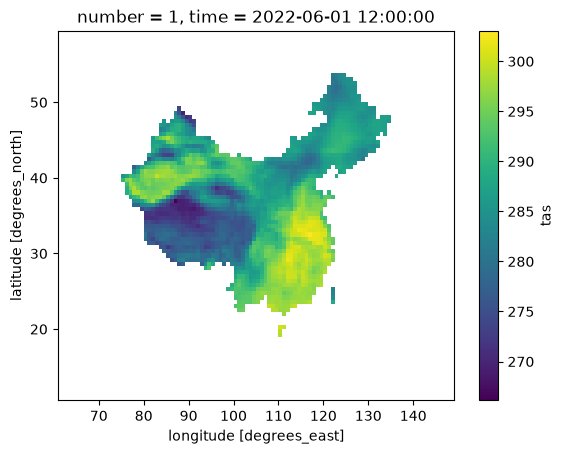

In [4]:
# Dataset check
import xarray as xr

ds_counterfactual_qm = xr.open_dataset("/home/users/weijia_6/Yangtze_code/HADGEM_2022_counterfactual_JunAug_qm_pergrid.nc", chunks={})
print(ds_counterfactual_qm["tas"].dims)
print(ds_counterfactual_qm["tas"].sizes)

# spot check
print(ds_counterfactual_qm["tas"].isel(number=0, time=0).min().values,
      ds_counterfactual_qm["tas"].isel(number=0, time=0).max().values)

ds_counterfactual_qm.tas[0,0].plot()

CDD_26 calculation based on the bias corrected datasets - 3 month sum for each grid

In [5]:
# CDD_26 calculation based on the bias corrected datasets - 3 month sum for each grid
import numpy as np
import xarray as xr

# ---------------- paths ----------------
factual_bc = "/home/users/weijia_6/Yangtze_code/HADGEM_2022_factual_JunAug_qm_pergrid.nc"
counter_bc = "/home/users/weijia_6/Yangtze_code/HADGEM_2022_counterfactual_JunAug_qm_pergrid.nc"

var_mod = "tas"  # daily mean temperature (K)

out_factual_cdd  = "/home/users/weijia_6/Yangtze_code/HADGEM_2022_factual_JunAug_CDD26.nc"
out_counter_cdd  = "/home/users/weijia_6/Yangtze_code/HADGEM_2022_counterfactual_JunAug_CDD26.nc"

# ---------------- threshold ----------------
Tbase = 26.0 + 273.15   # Kelvin

# ---------------- helper: compute CDD ----------------
def compute_cdd(in_path, out_path):
    ds = xr.open_dataset(in_path)
    da = ds[var_mod]   # (number, time, lat, lon)

    # mask of valid grid cells (True where not all NaN)
    mask = da.isnull().all(dim="time") == False

    # CDD = sum(max(T - Tbase, 0)) over time
    cdd = xr.where(da > Tbase, da - Tbase, 0.0).sum(dim="time")

    # apply mask to preserve NaNs outside China
    cdd = cdd.where(mask)

    # Save output
    cdd_ds = xr.Dataset({"CDD26": cdd}, coords=cdd.coords)
    encoding = {"CDD26": {"dtype": "float32", "zlib": True, "complevel": 4}}
    cdd_ds.to_netcdf(out_path, encoding=encoding)

    print("Saved:", out_path)

# ---------------- run for factual and counterfactual ----------------
compute_cdd(factual_bc,  out_factual_cdd)
compute_cdd(counter_bc,  out_counter_cdd)

Saved: /home/users/weijia_6/Yangtze_code/HADGEM_2022_factual_JunAug_CDD26.nc
Saved: /home/users/weijia_6/Yangtze_code/HADGEM_2022_counterfactual_JunAug_CDD26.nc


Calculate the popweighted CDD for each province and save it csv files

In [6]:
# Calculate the popweighted CDD for each province and save it csv files
# try having values for all 34 provinces correct version
import geopandas as gpd
import xarray as xr
import numpy as np
from shapely.geometry import Polygon
import pandas as pd

# -----------------------------
# Paths
# -----------------------------
shp_file     = "/home/users/weijia_6/Yangtze_code/geoBoundaries-CHN-ADM1-all/geoBoundaries-CHN-ADM1.shp"
cdd_f_path   = "/home/users/weijia_6/Yangtze_code/HADGEM_2022_factual_JunAug_CDD26.nc"
cdd_cf_path  = "/home/users/weijia_6/Yangtze_code/HADGEM_2022_counterfactual_JunAug_CDD26.nc"
pop_path     = "/home/users/weijia_6/Yangtze_code/ssp2_2020.nc"

pop_var = "ssp2_2020"
cdd_var = "CDD26"

# -----------------------------
# Load shapefile
# -----------------------------
gdf = gpd.read_file(shp_file).to_crs("EPSG:4326")
province_names = gdf["shapeName"].values

# -----------------------------
# Load population (SSP2 grid)
# -----------------------------
ds_pop = xr.open_dataset(pop_path)
pop = ds_pop[pop_var]  # (lat, lon)

# -----------------------------
# Load HadGEM CDD
# -----------------------------
ds_f  = xr.open_dataset(cdd_f_path)
ds_cf = xr.open_dataset(cdd_cf_path)

hg = ds_f[cdd_var]  # (number, latitude, longitude)
lat_hg = hg["latitude"]
lon_hg = hg["longitude"]

nens = ds_f.sizes["number"]

# -----------------------------
# Regrid population to HadGEM grid (same as OBS method)
# -----------------------------
pop_tmp = pop.rename({"lat": "latitude", "lon": "longitude"})
pop_rg_tmp = pop_tmp.interp(latitude=lat_hg, longitude=lon_hg, method="linear")
pop_rg = pop_rg_tmp.rename({"latitude": "lat", "longitude": "lon"})

# -----------------------------
# Build HadGEM grid polygons
# -----------------------------
lat = lat_hg.values
lon = lon_hg.values

def compute_bounds(coord):
    mid = (coord[:-1] + coord[1:]) / 2
    first = coord[0] - (mid[0] - coord[0])
    last  = coord[-1] + (coord[-1] - mid[-1])
    return np.concatenate([[first], mid, [last]])

lat_b = compute_bounds(lat)
lon_b = compute_bounds(lon)

grid_polygons = {}
for j in range(len(lat)):
    for i in range(len(lon)):
        poly = Polygon([
            (lon_b[i],   lat_b[j]),
            (lon_b[i+1], lat_b[j]),
            (lon_b[i+1], lat_b[j+1]),
            (lon_b[i],   lat_b[j+1])
        ])
        grid_polygons[(i, j)] = poly

# -----------------------------
# Precompute province masks
# -----------------------------
province_masks = []
for p, row in gdf.iterrows():
    geom = row.geometry
    mask = np.zeros((len(lat), len(lon)), dtype=bool)

    for j in range(len(lat)):
        for i in range(len(lon)):
            if grid_polygons[(i, j)].intersects(geom):
                mask[j, i] = True

    province_masks.append(mask)

province_masks = np.array(province_masks)

# -----------------------------
# Prepare output arrays
# -----------------------------
pw_f  = np.zeros((len(gdf), nens), dtype=np.float32)
pw_cf = np.zeros((len(gdf), nens), dtype=np.float32)

# -----------------------------
# Loop over ensemble members
# -----------------------------
for e in range(nens):
    print(f"Processing ensemble {e+1}/{nens}")

    cdd_f_e  = ds_f[cdd_var].isel(number=e)
    cdd_cf_e = ds_cf[cdd_var].isel(number=e)

    cdd_f_vals  = cdd_f_e.values
    cdd_cf_vals = cdd_cf_e.values

    for p in range(len(gdf)):
        mask = province_masks[p]
        pop_p = pop_rg.values[mask]

        pop_sum = np.nansum(pop_p)
        if pop_sum <= 0:
            pw_f[p, e]  = np.nan
            pw_cf[p, e] = np.nan
            continue

        cdd_f_p  = cdd_f_vals[mask]
        cdd_cf_p = cdd_cf_vals[mask]

        pw_f[p, e]  = np.nansum(cdd_f_p  * pop_p) / pop_sum
        pw_cf[p, e] = np.nansum(cdd_cf_p * pop_p) / pop_sum

# -----------------------------
# Save CSV
# -----------------------------
df_f  = pd.DataFrame(pw_f,  index=province_names)
df_cf = pd.DataFrame(pw_cf, index=province_names)

df_f.to_csv("/home/users/weijia_6/Yangtze_code/CDD26_factual_popweighted_provinces_correct.csv")
df_cf.to_csv("/home/users/weijia_6/Yangtze_code/CDD26_counterfactual_popweighted_provinces_correct.csv")

print("Done.")

Processing ensemble 1/525
Processing ensemble 2/525
Processing ensemble 3/525
Processing ensemble 4/525
Processing ensemble 5/525
Processing ensemble 6/525
Processing ensemble 7/525
Processing ensemble 8/525
Processing ensemble 9/525
Processing ensemble 10/525
Processing ensemble 11/525
Processing ensemble 12/525
Processing ensemble 13/525
Processing ensemble 14/525
Processing ensemble 15/525
Processing ensemble 16/525
Processing ensemble 17/525
Processing ensemble 18/525
Processing ensemble 19/525
Processing ensemble 20/525
Processing ensemble 21/525
Processing ensemble 22/525
Processing ensemble 23/525
Processing ensemble 24/525
Processing ensemble 25/525
Processing ensemble 26/525
Processing ensemble 27/525
Processing ensemble 28/525
Processing ensemble 29/525
Processing ensemble 30/525
Processing ensemble 31/525
Processing ensemble 32/525
Processing ensemble 33/525
Processing ensemble 34/525
Processing ensemble 35/525
Processing ensemble 36/525
Processing ensemble 37/525
Processing